In [13]:
from numpy import array
import numpy as np

epsilon = np.float32(0.017950773)

sample_cov = array([[ 2.81038778e-05, -2.55969061e-04,  7.65351542e-05],
       [-2.55969061e-04,  7.94864450e-02, -4.49731093e-02],
       [ 7.65351542e-05, -4.49731093e-02,  7.69346663e-02]])

# is cov semi  positive definite?
eigenvalues = np.linalg.eigvals(sample_cov)
print("Eigenvalues:", eigenvalues)

Eigenvalues: [2.71885314e-05 1.23202215e-01 3.32198112e-02]


In [10]:
# float32
from numpy import float32
dists = array([0.01743281 for i in range(1000)],
      dtype=float32)

In [9]:
dists = [np.float32(0.017441988), np.float32(0.017445505), np.float32(0.017448246), np.float32(0.017593026), np.float32(0.01775688), np.float32(0.017855585), np.float32(0.017917633), np.float32(0.017925858), np.float32(0.01793176), np.float32(0.017950773), np.float32(0.017971098), np.float32(0.018012166), np.float32(0.018106163), np.float32(0.01814115), np.float32(0.018268585), np.float32(0.018400371), np.float32(0.018406272), np.float32(0.01856196), np.float32(0.01857543), np.float32(0.01865244), np.float32(0.01866424), np.float32(0.018682182), np.float32(0.018738031), np.float32(0.018889248), np.float32(0.018892944), np.float32(0.01889515), np.float32(0.019064069), np.float32(0.019114494), np.float32(0.01913768), np.float32(0.019171894), np.float32(0.019176304), np.float32(0.019247413), np.float32(0.01925987), np.float32(0.019274473), np.float32(0.019436777), np.float32(0.019545496), np.float32(0.019605637), np.float32(0.019684374), np.float32(0.019865453), np.float32(0.019879937), np.float32(0.01991868), np.float32(0.0199427), np.float32(0.019949853), np.float32(0.020022392), np.float32(0.020162523), np.float32(0.020198107), np.float32(0.020283341), np.float32(0.020287156), np.float32(0.020480573), np.float32(0.020553708), np.float32(0.02060312), np.float32(0.020637155), np.float32(0.020687401), np.float32(0.020762742), np.float32(0.020766318), np.float32(0.020837665), np.float32(0.020844817), np.float32(0.02086234), np.float32(0.020883441), ...]

In [1]:
import re
from pathlib import Path

import rootutils

rootutils.setup_root(Path.cwd(), indicator=".project-root", pythonpath=True)

import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib.colors import ListedColormap
from omegaconf import OmegaConf
from PIL import Image

from src.inference import load_model_and_transform
from src.viaABC.systems import Spatial2D

plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


In [2]:
# -----------------------------
# 1. Configuration
# -----------------------------
PROJECT_ROOT = Path(rootutils.find_root(Path.cwd(), indicator=".project-root"))
SAMPLE_ID = "sample_1"

# Update this to a training run directory that exists on your local machine.
RUN_FOLDER_PATH = PROJECT_ROOT / "run" / "train" / "spatial2D" / "2026-04-26_00-26-59_submit"
CHECKPOINT_SUBSTR = "last"

# Keep the inference tiny but still numerically valid for debugging.
ABC_DEBUG_CFG = {
    "num_particles": 10,
    "k": 10,
    "q_threshold": 0.90,
    "max_generations": 1,
    "num_workers": 10,
    "simulation_batch_size": 1,
    "max_pending_simulations": 1,
}

if ABC_DEBUG_CFG["num_particles"] < 2:
    raise ValueError("Please keep num_particles >= 2 for debugging.")

BASE_INFERENCE_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "inference.yaml")
SPATIAL2D_INFERENCE_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "inference" / "spatial2D.yaml")
DATA_CFG = OmegaConf.load(PROJECT_ROOT / "configs" / "data" / "spatial2D.yaml")
INFERENCE_CFG = OmegaConf.merge(BASE_INFERENCE_CFG, SPATIAL2D_INFERENCE_CFG)
INFERENCE_CFG.data = DATA_CFG

PARAM_NAMES = ["alpha", "beta", "gamma"]
STATE_CMAP = ListedColormap([
    "#d73027",
    "#fee08b",
    "#4575b4",
    "#2b1744",
    "#1a9850",
    "#d9d9d9",
])

print("RUN_FOLDER_PATH:", RUN_FOLDER_PATH)
print("SAMPLE_ID:", SAMPLE_ID)
print("ABC_DEBUG_CFG:", ABC_DEBUG_CFG)


RUN_FOLDER_PATH: /home/kangyu/project/viaABC/run/train/spatial2D/2026-04-26_00-26-59_submit
SAMPLE_ID: sample_1
ABC_DEBUG_CFG: {'num_particles': 10, 'k': 10, 'q_threshold': 0.9, 'max_generations': 1, 'num_workers': 10, 'simulation_batch_size': 1, 'max_pending_simulations': 1}


In [3]:
# -----------------------------
# 2. Minimal helper logic
# -----------------------------
sample_cfg = OmegaConf.to_container(INFERENCE_CFG.data.observation_samples[SAMPLE_ID], resolve=False)
txt_path = Path(str(sample_cfg["txt"]).replace("${paths.data_dir}", str(PROJECT_ROOT / "data")))

image_candidates = []
if sample_cfg.get("image") is not None:
    image_candidates.append(Path(str(sample_cfg["image"]).replace("${paths.data_dir}", str(PROJECT_ROOT / "data"))))

match = re.search(r"(\d+)$", SAMPLE_ID)
if match is not None:
    idx = match.group(1)
    image_candidates.extend([
        PROJECT_ROOT / "data" / "spatial2D" / f"img{idx}.jpg",
        PROJECT_ROOT / "data" / "spatial2D" / f"image{idx}_processed.jpg",
        PROJECT_ROOT / "data" / "spatial2D" / f"image{idx}.jpg",
    ])

raw_image_path = next((path for path in image_candidates if path.exists()), None)


def draw_grid(ax, grid, title):
    ax.imshow(grid, cmap=STATE_CMAP, vmin=0, vmax=5)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


def weighted_quantile(values, quantile, weights):
    values = np.asarray(values)
    weights = np.asarray(weights)
    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cumulative = np.cumsum(weights) - 0.5 * weights
    cumulative = cumulative / weights.sum()
    return np.interp(quantile, cumulative, values)

/home/kangyu/micromamba/envs/viaabc310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/kangyu/micromamba/envs/viaabc310/lib/python3.10/site-packages/lightning/pytorch/utilities/parsing.py:209: Attribute 'net' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['net'])`.
INFO:src.viaABC.viaABC:Initializing viaABC class
INFO:src.viaABC.viaABC:Model updated
INFO:src.viaABC.viaABC:viaABC class initialized with the following parameters:
INFO:src.viaABC.viaABC:num_parameters: 3
INFO:src.viaABC.viaABC:Mu: [5.e-02 1.e-04 2.e-01]
INFO:src.viaABC.viaABC:Sigma: [1 1 1]
INFO:src.viaABC.viaABC:t0: 0
INFO:src.viaABC.viaABC:tmax: 24
INFO:src.viaABC.viaABC:time_space: None
INFO:src.viaABC.viaABC:pooling_method: no_cls
I

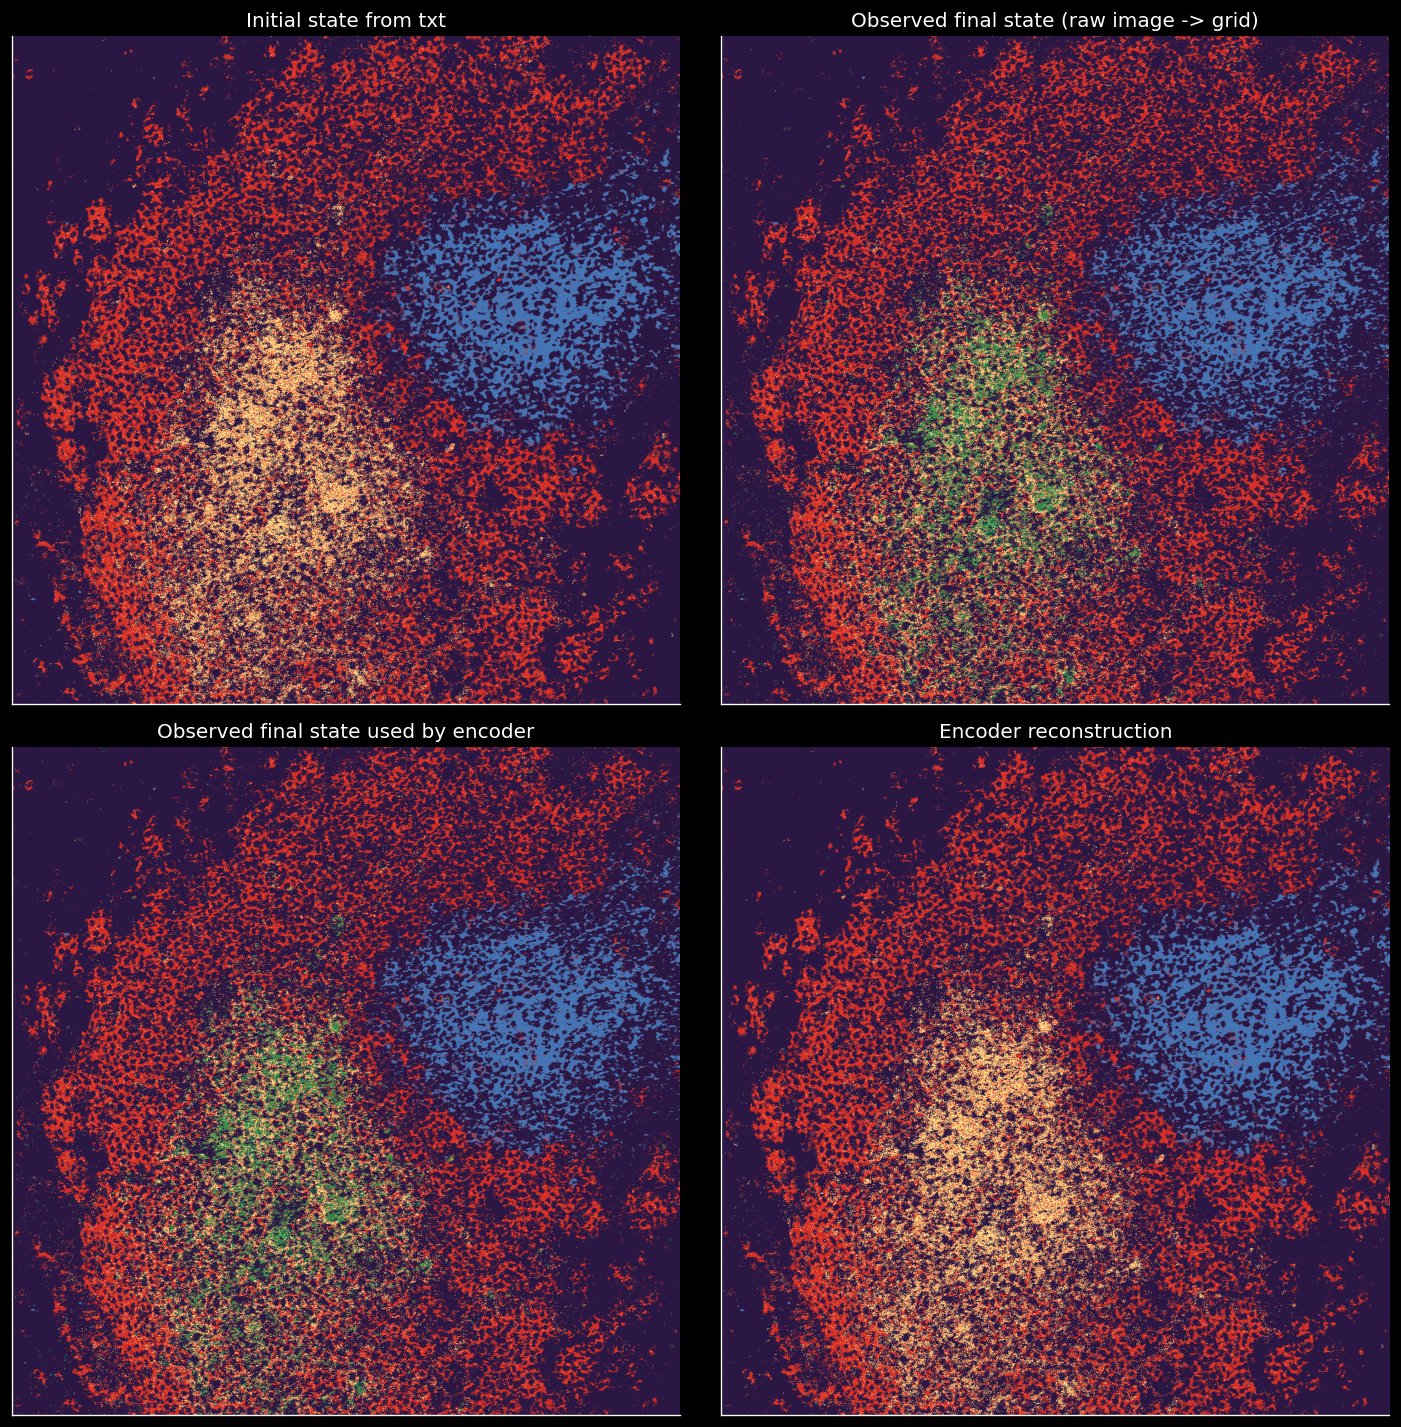

txt path: /home/kangyu/project/viaABC/data/spatial2D/initial_grid1_cpp.txt
raw image path: /home/kangyu/project/viaABC/data/spatial2D/img1.jpg
device: cuda:0
transform: None
encoded observation shape: (1, 5625, 256)
recon == observed: 0.8557652777777778
recon == initial: 0.9994625
changed pixels ratio: 0.14393125
recon == observed on changed pixels: 0.0005886297952822769
recon == initial on changed pixels: 0.9989626606066747
observed labels on changed pixels: {np.uint8(0): np.int64(65229), np.uint8(1): np.int64(21638), np.uint8(2): np.int64(13413), np.uint8(3): np.int64(66656), np.uint8(4): np.int64(40325)}
initial labels on changed pixels: {np.uint8(0): np.int64(70791), np.uint8(1): np.int64(57157), np.uint8(2): np.int64(13589), np.uint8(3): np.int64(65724)}
recon labels on changed pixels: {np.int64(0): np.int64(70769), np.int64(1): np.int64(57126), np.int64(2): np.int64(13588), np.int64(3): np.int64(65778)}


In [4]:
# -----------------------------
# 3. Load the real model and the real system interface
# -----------------------------
runtime_cfg = OmegaConf.create({
    "run_folder_path": str(RUN_FOLDER_PATH),
    "checkpoint_substr": CHECKPOINT_SUBSTR,
})

model, transform = load_model_and_transform(runtime_cfg)

system = Spatial2D(
    model=model,
    transform=transform,
    sample_id=SAMPLE_ID,
    pooling_method=INFERENCE_CFG.system.pooling_method,
    metric=INFERENCE_CFG.system.metric,
)

initial_grid = np.loadtxt(txt_path, dtype=np.uint8)
observed_grid = system._observation_grids[0]
raw_image = np.array(Image.open(raw_image_path)) if raw_image_path is not None else None
raw_image_grid = system.image_to_grid(raw_image) if raw_image is not None else None

obs_tensor =  torch.from_numpy(system.observational_data).unsqueeze(0).float().to(model.device)
with torch.no_grad():
    recon_tokens = model.model.forward(obs_tensor, mask_ratio=0.0)[-1]
    recon_grid = model.model.unpatchify(recon_tokens).detach().cpu().numpy()[0].argmax(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
draw_grid(axes[0, 0], initial_grid, "Initial state from txt")
if raw_image is not None:
    draw_grid(axes[0, 1], raw_image_grid, "Observed final state (raw image -> grid)")
else:
    draw_grid(axes[0, 1], observed_grid, "Observed final state")
draw_grid(axes[1, 0], observed_grid, "Observed final state used by encoder")
draw_grid(axes[1, 1], recon_grid, "Encoder reconstruction")
fig.tight_layout()
plt.show()

print("txt path:", txt_path)
print("raw image path:", raw_image_path)
print("device:", model.device)
print("transform:", type(transform).__name__ if transform is not None else None)
print("encoded observation shape:", system.encoded_observational_data.shape)
print("recon == observed:", (recon_grid == observed_grid).mean())
print("recon == initial:", (recon_grid == initial_grid).mean())
changed_mask = observed_grid != initial_grid

print("changed pixels ratio:", changed_mask.mean())
print("recon == observed on changed pixels:", (recon_grid[changed_mask] == observed_grid[changed_mask]).mean())
print("recon == initial on changed pixels:", (recon_grid[changed_mask] == initial_grid[changed_mask]).mean())

print("observed labels on changed pixels:", dict(zip(*np.unique(observed_grid[changed_mask], return_counts=True))))
print("initial labels on changed pixels:", dict(zip(*np.unique(initial_grid[changed_mask], return_counts=True))))
print("recon labels on changed pixels:", dict(zip(*np.unique(recon_grid[changed_mask], return_counts=True))))


In [6]:
print((system.labels2map(observed_grid) == system.observational_data).sum())
system.observational_data.shape[0] * system.observational_data.shape[1] * system.observational_data.shape[2]

8640000


8640000

### Issue: Input final state to the model and reconstruction give back an initial state result.

1. 验证`simulate`在不同的dt下是否能够输出稳定且有效的绿色结果。使用真参数分布
2. 读取training_dataset，还原可视化结果，观察初始态和终态的图像是否合理
3. 检查 generate_training_data是否有业务逻辑错误

true parameter draws shape: (8, 3)
original dt: 0.4
dt values: [0.8, 0.4, 0.2, 0.1]
t0, tmax: 0 24

Summary by dt
dt=0.8 steps=  30 effective_t_end=24 leftover=0 | green mean/std/min/max=0.000036/0.000084/0.000000/0.000273 | hotspot_mean=0.064824 green+hotspot_mean=0.064860 changed_mean=0.064860 valid_green_fraction=0.12
dt=0.4 steps=  60 effective_t_end=24 leftover=0 | green mean/std/min/max=0.000035/0.000080/0.000000/0.000253 | hotspot_mean=0.064818 green+hotspot_mean=0.064853 changed_mean=0.064853 valid_green_fraction=0.12
dt=0.2 steps= 120 effective_t_end=24 leftover=0 | green mean/std/min/max=0.000033/0.000075/0.000000/0.000247 | hotspot_mean=0.064815 green+hotspot_mean=0.064848 changed_mean=0.064848 valid_green_fraction=0.12
dt=0.1 steps= 240 effective_t_end=24 leftover=0 | green mean/std/min/max=0.000030/0.000068/0.000000/0.000220 | hotspot_mean=0.064831 green+hotspot_mean=0.064861 changed_mean=0.064861 valid_green_fraction=0.12

Baseline dt for pairwise comparison: 0.4
dt=0.8 m

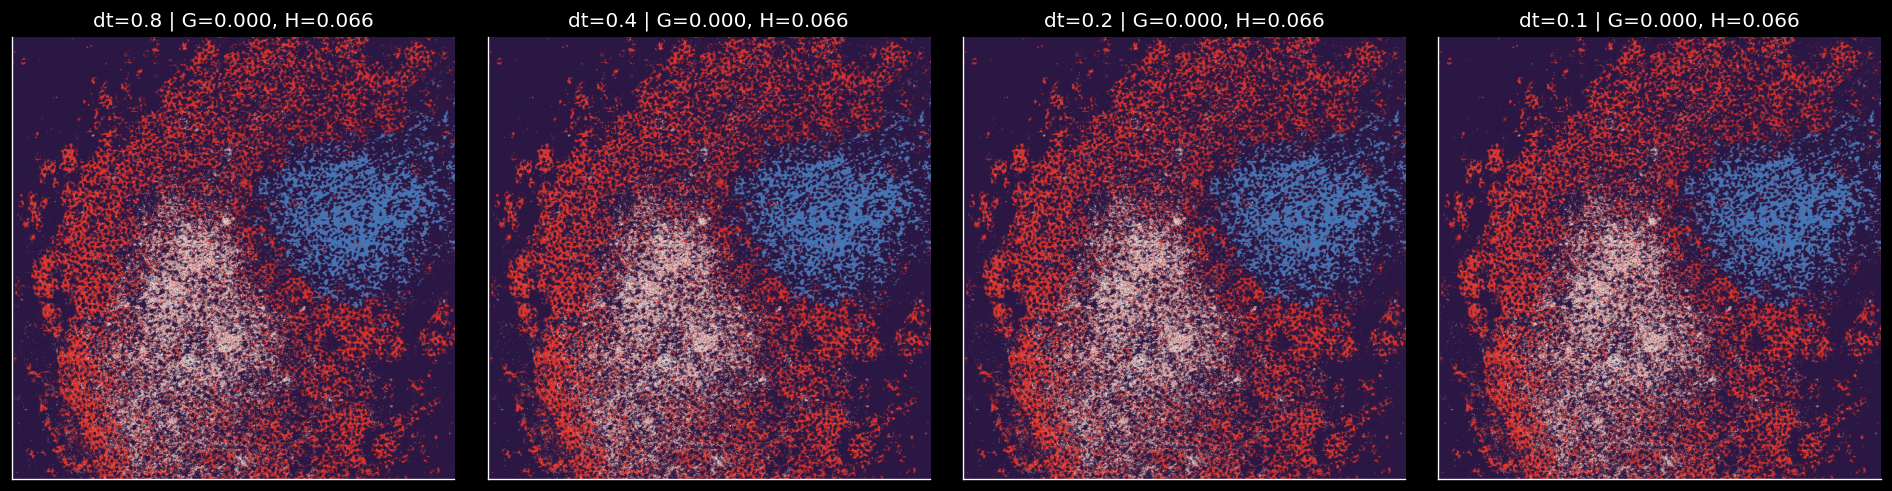

In [5]:
# -----------------------------
# 4. Check whether simulate keeps stable green outputs across dt
# -----------------------------
# This uses the current Spatial2D prior as the "true" parameter distribution:
# alpha, beta, gamma ~ system.sample_priors(). The same parameter draws are reused
# for every dt so changes are attributable to dt rather than different parameters.
DT_VALUES = [0.8, 0.4, 0.2, 0.1]
N_TRUE_PARAM_DRAWS = 8
N_REPEATS_PER_PARAM = 2
TRUE_PARAM_SEED = 123
GREEN_LABEL = 4
HOTSPOT_LABEL = 5
GREEN_VALID_THRESHOLD = 1e-4

rng_state = np.random.get_state()
np.random.seed(TRUE_PARAM_SEED)
true_parameter_draws = np.stack([system.sample_priors() for _ in range(N_TRUE_PARAM_DRAWS)], axis=0)
np.random.set_state(rng_state)

original_dt = system.dt
records = []
representative_grids = {}

print("true parameter draws shape:", true_parameter_draws.shape)
print("original dt:", original_dt)
print("dt values:", DT_VALUES)
print("t0, tmax:", system.t0, system.tmax)

for dt in DT_VALUES:
    system.dt = float(dt)
    steps = int((system.tmax - system.t0) / system.dt)
    effective_t_end = system.t0 + steps * system.dt
    leftover = system.tmax - effective_t_end

    for param_idx, theta in enumerate(true_parameter_draws):
        for repeat_idx in range(N_REPEATS_PER_PARAM):
            sim_grid, status = system.simulate(theta)
            counts = np.bincount(sim_grid.reshape(-1), minlength=6)
            ratios = counts / counts.sum()
            changed_from_initial = sim_grid != initial_grid

            records.append({
                "dt": float(dt),
                "steps": steps,
                "effective_t_end": effective_t_end,
                "leftover": leftover,
                "param_idx": param_idx,
                "repeat_idx": repeat_idx,
                "status": status,
                "alpha": theta[0],
                "beta": theta[1],
                "gamma": theta[2],
                "green_ratio": ratios[GREEN_LABEL],
                "hotspot_ratio": ratios[HOTSPOT_LABEL],
                "green_or_hotspot_ratio": ratios[GREEN_LABEL] + ratios[HOTSPOT_LABEL],
                "changed_from_initial_ratio": changed_from_initial.mean(),
                "valid_green": ratios[GREEN_LABEL] > GREEN_VALID_THRESHOLD,
                "label_counts": counts,
            })

            if dt not in representative_grids:
                representative_grids[dt] = sim_grid.copy()

system.dt = original_dt

# Summarize without pandas so the cell stays lightweight.
summary_rows = []
for dt in DT_VALUES:
    dt_records = [record for record in records if record["dt"] == float(dt)]
    green = np.array([record["green_ratio"] for record in dt_records])
    hotspot = np.array([record["hotspot_ratio"] for record in dt_records])
    green_or_hotspot = np.array([record["green_or_hotspot_ratio"] for record in dt_records])
    changed = np.array([record["changed_from_initial_ratio"] for record in dt_records])
    valid_green = np.array([record["valid_green"] for record in dt_records])
    steps = dt_records[0]["steps"]
    effective_t_end = dt_records[0]["effective_t_end"]
    leftover = dt_records[0]["leftover"]

    summary_rows.append({
        "dt": float(dt),
        "steps": steps,
        "effective_t_end": effective_t_end,
        "leftover": leftover,
        "green_mean": green.mean(),
        "green_std": green.std(),
        "green_min": green.min(),
        "green_max": green.max(),
        "hotspot_mean": hotspot.mean(),
        "green_or_hotspot_mean": green_or_hotspot.mean(),
        "changed_mean": changed.mean(),
        "valid_green_fraction": valid_green.mean(),
    })

print("\nSummary by dt")
for row in summary_rows:
    print(
        "dt={dt:.4g} steps={steps:4d} effective_t_end={effective_t_end:.6g} "
        "leftover={leftover:.3g} | green mean/std/min/max="
        "{green_mean:.6f}/{green_std:.6f}/{green_min:.6f}/{green_max:.6f} | "
        "hotspot_mean={hotspot_mean:.6f} green+hotspot_mean={green_or_hotspot_mean:.6f} "
        "changed_mean={changed_mean:.6f} valid_green_fraction={valid_green_fraction:.2f}"
        .format(**row)
    )

# Compare dt values against the baseline dt closest to the original system dt.
baseline_dt = min(DT_VALUES, key=lambda value: abs(value - original_dt))
baseline_records = [record for record in records if record["dt"] == float(baseline_dt)]
baseline_green = np.array([record["green_ratio"] for record in baseline_records])
print(f"\nBaseline dt for pairwise comparison: {baseline_dt}")
for dt in DT_VALUES:
    dt_green = np.array([record["green_ratio"] for record in records if record["dt"] == float(dt)])
    mean_abs_delta = np.abs(dt_green - baseline_green).mean()
    print(f"dt={dt:.4g} mean |green_ratio - baseline|: {mean_abs_delta:.6f}")

# Visualize one representative simulation per dt using the same draw_grid helper.
fig, axes = plt.subplots(1, len(DT_VALUES), figsize=(4 * len(DT_VALUES), 4))
if len(DT_VALUES) == 1:
    axes = [axes]

for ax, dt in zip(axes, DT_VALUES):
    grid = representative_grids[dt]
    green_ratio = (grid == GREEN_LABEL).mean()
    hotspot_ratio = (grid == HOTSPOT_LABEL).mean()
    draw_grid(ax, grid, f"dt={dt} | G={green_ratio:.3f}, H={hotspot_ratio:.3f}")

fig.tight_layout()
plt.show()

# Optional detailed records are kept for ad hoc inspection in later cells.
dt_stability_records = records
dt_stability_summary = summary_rows
true_parameter_draws_for_dt_check = true_parameter_draws

